In [2]:
# === DEMO FILES INVENTORY ===
import os
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from IPython.display import Audio, display

# Define directories
DEMO_DIR = '/fs/scratch/<allocation>/nov_demo'
AUDIO_DIR = '/fs/scratch/<allocation>/Audio Files'

# Set global variables for analysis
SAMPLE_RATE = 200000  # Default sample rate for binary files

# Quick file inventory
demo_files = sorted(glob.glob(os.path.join(DEMO_DIR, '*')))
audio_files = sorted(glob.glob(os.path.join(AUDIO_DIR, '*')))
real_files = [f for f in demo_files if f.endswith('_real.bin')]

print(f"Found {len(real_files)} .real files and {len(audio_files)} audio files")


Found 16 .real files and 7 audio files


In [3]:
# === FILE SELECTION LIST ===
# Edit this list to choose which files to analyze
# Format: [(real_file_path, mp3_file_path), ...]

# Get available files
demo_files = sorted(glob.glob('/fs/scratch/<allocation>/nov_demo/*_real.bin'))
audio_files = sorted(glob.glob('/fs/scratch/<allocation>/Audio Files/*.mp3'))

# EDIT THIS LIST - Add/remove file pairs as needed
SELECTED_FILES = [
    ('/fs/scratch/<allocation>/nov_demo/alice_chap_1_real.bin', '/fs/scratch/<allocation>/Alice_In_Wonderland_mp3/Alice_In_Wonderland_ch_01.mp3')
]

# Binary-only files (no MP3 pair needed)
BINARY_ONLY_FILES = [
    '/fs/scratch/<allocation>/nov_demo/idle_97_real.bin'
]


# Create combined list for processing
ALL_ANALYSIS_FILES = SELECTED_FILES.copy()  # File pairs
ALL_BINARY_FILES = [real for real, mp3 in SELECTED_FILES] + BINARY_ONLY_FILES  # All binary files

# Display selected files
print("🎯 SELECTED FILES FOR ANALYSIS:")
for i, (real_file, mp3_file) in enumerate(SELECTED_FILES, 1):
    print(f"{i}. {os.path.basename(real_file)} ↔ {os.path.basename(mp3_file)}")

if BINARY_ONLY_FILES:
    print(f"\n📁 BINARY-ONLY FILES (no MP3 pair):")
    for i, real_file in enumerate(BINARY_ONLY_FILES, 1):
        print(f"{i}. {os.path.basename(real_file)} (binary analysis only)")

print(f"\nTotal: {len(SELECTED_FILES)} file pairs + {len(BINARY_ONLY_FILES)} binary-only files")

🎯 SELECTED FILES FOR ANALYSIS:
1. alice_chap_1_real.bin ↔ Alice_In_Wonderland_ch_01.mp3

📁 BINARY-ONLY FILES (no MP3 pair):
1. idle_97_real.bin (binary analysis only)

Total: 1 file pairs + 1 binary-only files


# Demo Files Visualization

This notebook analyzes audio files from the demo directories for powerline interference analysis.

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?



🔍 Finding time offset for alice_chap_1_real.bin...
   Peak found at sample 661,798 (3.309 seconds)
   → Real signal starts 3.309s after beginning
   → Aligning real signal to start from this peak


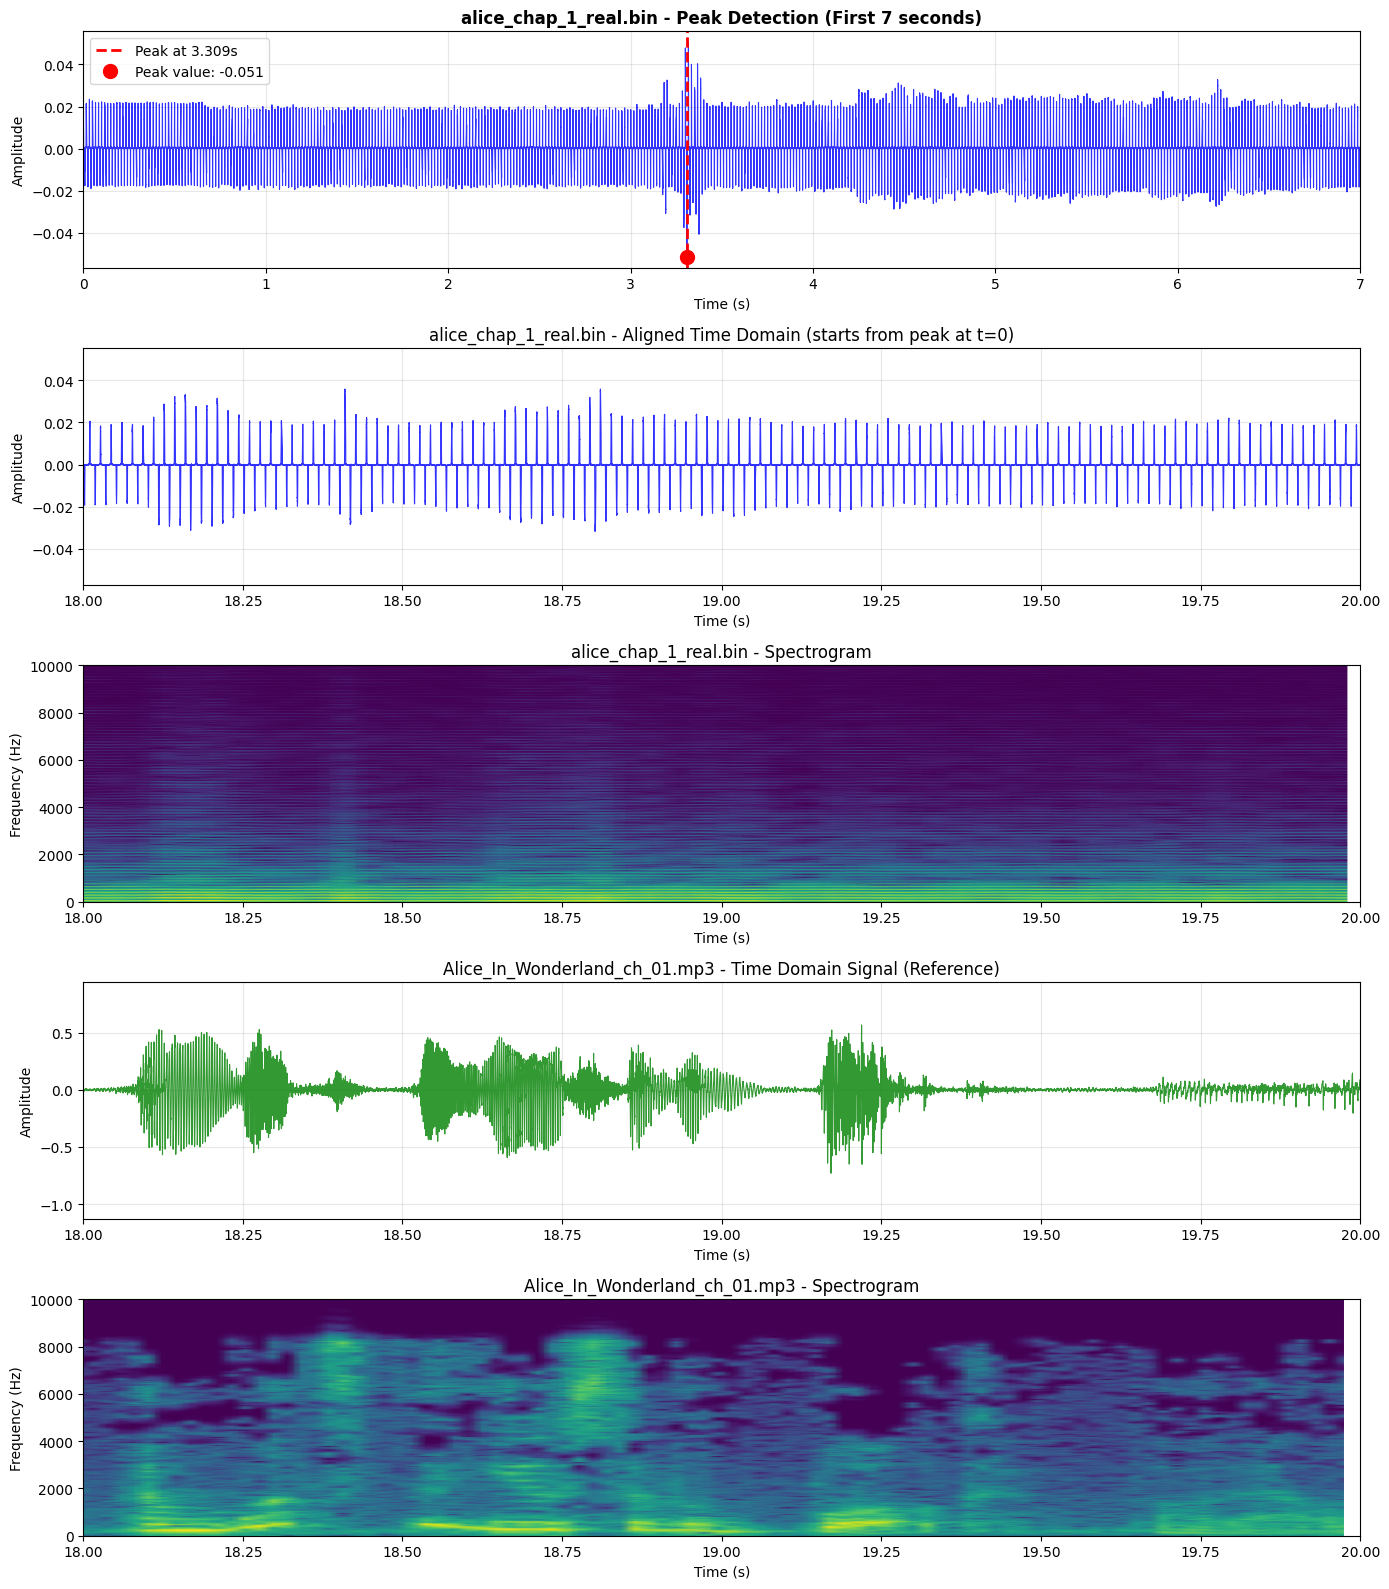

In [17]:
# === TIME DOMAIN vs FREQUENCY DOMAIN COMPARISON ===
import os, glob, numpy as np, matplotlib.pyplot as plt
from scipy.signal import spectrogram, welch
try:
    import librosa
    librosa_available = True
except ImportError:
    librosa_available = False
    print("Warning: librosa not available, cannot load MP3 files")

def find_time_offset_from_peak(real_data, fs_real, search_duration_sec=7):
    """
    Find time offset by detecting peak in real signal within first few seconds.
    Returns offset in seconds where the real signal should start (peak location).
    """
    # Analyze first N seconds
    max_samples = min(len(real_data), int(search_duration_sec * fs_real))
    search_segment = real_data[:max_samples]
    
    # Find absolute peak (maximum absolute value)
    peak_idx = np.argmax(np.abs(search_segment))
    offset_seconds = peak_idx / fs_real
    
    return offset_seconds, peak_idx

# Use selected files from the list above
if 'SELECTED_FILES' not in globals():
    print("⚠️ Please run the FILE SELECTION cell above first")
    SELECTED_FILES = []

if librosa_available and len(SELECTED_FILES) > 0:
    # Process selected file pairs
    for idx, (real_file, mp3_file) in enumerate(SELECTED_FILES):
        real_name = os.path.basename(real_file)
        mp3_name = os.path.basename(mp3_file)
        
        try:
            # Load binary file
            real_data = np.fromfile(real_file, dtype=np.float32)
            if len(real_data) == 0:
                continue
            
            # Load MP3 file
            mp3_data, mp3_sr = librosa.load(mp3_file, sr=None, mono=True)
            
            # Use sample rate from globals or MP3 file
            fs_real = globals().get('SAMPLE_RATE', 200000)
            fs_mp3 = mp3_sr
            
            # Find time offset from peak in real signal
            print(f"\n🔍 Finding time offset for {real_name}...")
            offset_sec, peak_sample = find_time_offset_from_peak(real_data, fs_real, search_duration_sec=7)
            
            print(f"   Peak found at sample {peak_sample:,} ({offset_sec:.3f} seconds)")
            print(f"   → Real signal starts {offset_sec:.3f}s after beginning")
            print(f"   → Aligning real signal to start from this peak")
            
            # Shift real data to start from peak
            real_data_aligned = real_data[peak_sample:]
            
            # Create time axis for both files
            t_real = np.arange(len(real_data_aligned)) / float(fs_real)
            t_mp3 = np.arange(len(mp3_data)) / float(fs_mp3)
            
            # Limit to 80 seconds
            max_time = 20
            max_samples_real = min(len(real_data_aligned), int(max_time * fs_real))
            max_samples_mp3 = min(len(mp3_data), int(max_time * fs_mp3))
            
            show_real = real_data_aligned[:max_samples_real]
            show_mp3 = mp3_data[:max_samples_mp3]
            t_real_show = t_real[:max_samples_real]
            t_mp3_show = t_mp3[:max_samples_mp3]
            
            # Also show original unaligned data for first 7 seconds
            search_samples = int(7 * fs_real)
            original_segment = real_data[:search_samples]
            t_original = np.arange(len(original_segment)) / fs_real
            
            # Create comparison plot: Peak detection + Both signals aligned
            fig, axes = plt.subplots(5, 1, figsize=(14, 16))
            
            # 1. Original real signal with peak marked (first 7 seconds)
            axes[0].plot(t_original, original_segment, 'b-', linewidth=0.8, alpha=0.8)
            axes[0].axvline(x=offset_sec, color='red', linestyle='--', linewidth=2, 
                           label=f'Peak at {offset_sec:.3f}s')
            axes[0].plot(offset_sec, original_segment[peak_sample], 'ro', markersize=10, 
                        label=f'Peak value: {original_segment[peak_sample]:.3f}')
            axes[0].set_title(f'{real_name} - Peak Detection (First 7 seconds)', 
                             fontsize=12, fontweight='bold')
            axes[0].set_xlabel('Time (s)')
            axes[0].set_ylabel('Amplitude')
            axes[0].grid(True, alpha=0.3)
            axes[0].legend()
            axes[0].set_xlim(0, 7)
            
            # 2. Binary file - Time Domain (aligned, starts from peak)
            axes[1].plot(t_real_show, show_real - np.mean(show_real), 'b-', linewidth=0.8, alpha=0.8)
            axes[1].set_title(f'{real_name} - Aligned Time Domain (starts from peak at t=0)')
            axes[1].set_xlabel('Time (s)')
            axes[1].set_ylabel('Amplitude')
            axes[1].grid(True, alpha=0.3)
            axes[1].set_xlim(18, 20)

            # 3. Powerline - Spectrogram
            f_spec_real, t_spec_real, Sxx_real = spectrogram(show_real, fs=fs_real, nperseg=1024*8, noverlap=128)
            im2 = axes[2].pcolormesh(t_spec_real, f_spec_real, 10 * np.log10(Sxx_real + 1e-12), 
                                   shading='gouraud', cmap='viridis')
            axes[2].set_title(f'{real_name} - Spectrogram')
            axes[2].set_xlabel('Time (s)')
            axes[2].set_ylabel('Frequency (Hz)')
            axes[2].set_ylim(0, 10000)
            axes[2].set_xlim(18, 20)
            
            # 4. MP3 file - Time Domain
            axes[3].plot(t_mp3_show, show_mp3, 'g-', linewidth=0.8, alpha=0.8)
            axes[3].set_title(f'{mp3_name} - Time Domain Signal (Reference)')
            axes[3].set_xlabel('Time (s)')
            axes[3].set_ylabel('Amplitude')
            axes[3].grid(True, alpha=0.3)
            axes[3].set_xlim(18, 20)

            # 5. MP3 file - Spectrogram
            f_spec_mp3, t_spec_mp3, Sxx_mp3 = spectrogram(show_mp3, fs=fs_mp3, nperseg=512, noverlap=32)
            im4 = axes[4].pcolormesh(t_spec_mp3, f_spec_mp3, 10 * np.log10(Sxx_mp3 + 1e-12), 
                                   shading='gouraud', cmap='viridis')
            axes[4].set_title(f'{mp3_name} - Spectrogram')
            axes[4].set_xlabel('Time (s)')
            axes[4].set_ylabel('Frequency (Hz)')
            axes[4].set_ylim(0, 10000)
            axes[4].set_xlim(18, 20)
            

            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f'Error processing {real_name}/{mp3_name}: {e}')
            import traceback
            traceback.print_exc()
            continue

else:
    if not librosa_available:
        print("Cannot perform comparison - librosa is required")
    else:
        print("No files selected for analysis")


In [ ]:
# === ODD HARMONICS vs MP3 SPECTROGRAM COMPARISON ===
from scipy.signal import spectrogram, butter, sosfiltfilt, hilbert

def extract_harmonic_spectrogram(data, fs, fundamental=60, max_freq=10000, bandwidth=20):
    """
    Extract odd harmonics and create a 2D image showing harmonic evolution over time
    """
    harmonic_freqs = []
    harmonic_numbers = []
    n = 1
    while True:
        harmonic_freq = fundamental * (2*n - 1)
        if harmonic_freq > max_freq:
            break
        harmonic_freqs.append(harmonic_freq)
        harmonic_numbers.append(2*n - 1)
        n += 1
    
    print(f"   Extracting {len(harmonic_freqs)} odd harmonics up to {harmonic_freqs[-1]:.0f} Hz")
    
    harmonic_envelopes = []
    for harmonic_freq in harmonic_freqs:
        lowcut = harmonic_freq - bandwidth/2
        highcut = harmonic_freq + bandwidth/2
        
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        sos = butter(5, [low, high], btype='band', analog=False, output='sos')
        filtered = sosfiltfilt(sos, data)
        
        analytic_signal = hilbert(filtered)
        envelope = np.abs(analytic_signal)
        harmonic_envelopes.append(envelope)
    
    harmonic_matrix = np.array(harmonic_envelopes)
    time_axis = np.arange(harmonic_matrix.shape[1]) / fs
    
    return harmonic_matrix, harmonic_freqs, harmonic_numbers, time_axis

if librosa_available and len(SELECTED_FILES) > 0:
    for idx, (real_file, mp3_file) in enumerate(SELECTED_FILES):
        real_name = os.path.basename(real_file)
        mp3_name = os.path.basename(mp3_file)
        
        try:
            # Load binary file
            real_data = np.fromfile(real_file, dtype=np.float32)
            if len(real_data) == 0:
                continue
            
            # Load MP3 file
            mp3_data, mp3_sr = librosa.load(mp3_file, sr=None, mono=True)
            
            # Use sample rate from globals
            fs_real = globals().get('SAMPLE_RATE', 200000)
            fs_mp3 = mp3_sr
            
            # Find peak and align signal
            offset_sec, peak_sample = find_time_offset_from_peak(real_data, fs_real, search_duration_sec=7)
            real_data_aligned = real_data[peak_sample:]
            
            print(f"\n🎵 Extracting Odd 60 Hz Harmonics for Comparison...")
            
            analysis_duration = 60.0
            max_samples_real = min(len(real_data_aligned), int(analysis_duration * fs_real))
            max_samples_mp3 = min(len(mp3_data), int(analysis_duration * fs_mp3))
            
            analysis_real = real_data_aligned[:max_samples_real]
            analysis_mp3 = mp3_data[:max_samples_mp3]
            
            harmonic_matrix, harmonic_freqs, harmonic_numbers, t_harmonics = extract_harmonic_spectrogram(
                analysis_real, fs_real, fundamental=60, max_freq=10000, bandwidth=20
            )
            
            print(f"   Computing MP3 spectrogram for comparison...")
            f_mp3, t_mp3, Sxx_mp3 = spectrogram(analysis_mp3, fs=fs_mp3, 
                                                 nperseg=2048, noverlap=1536)
            
            Sxx_mp3_db = 10 * np.log10(Sxx_mp3 + 1e-12)
            harmonic_matrix_db = 20 * np.log10(harmonic_matrix + 1e-12)
            
            # Downsample harmonic matrix if too large
            max_time_samples = 4000
            if harmonic_matrix_db.shape[1] > max_time_samples:
                downsample_factor = harmonic_matrix_db.shape[1] // max_time_samples
                harmonic_matrix_db = harmonic_matrix_db[:, ::downsample_factor]
                print(f"   Downsampling harmonic matrix by factor of {downsample_factor}")
            
            # Downsample MP3 spectrogram if too large
            if Sxx_mp3_db.shape[1] > max_time_samples:
                downsample_factor_mp3 = Sxx_mp3_db.shape[1] // max_time_samples
                Sxx_mp3_db = Sxx_mp3_db[:, ::downsample_factor_mp3]
                print(f"   Downsampling MP3 spectrogram by factor of {downsample_factor_mp3}")
            
            fig, axes = plt.subplots(3, 1, figsize=(16, 14))
            
            extent_harmonics = [0, analysis_duration, 0, len(harmonic_freqs)]
            im1 = axes[0].imshow(harmonic_matrix_db, aspect='auto', origin='lower',
                                extent=extent_harmonics, cmap='viridis', interpolation='bilinear')
            
            axes[0].set_title(f'{real_name} - Odd 60 Hz Harmonics (2D Image)', 
                             fontsize=14, fontweight='bold')
            axes[0].set_xlabel('Time (s)', fontsize=12)
            axes[0].set_ylabel('Harmonic Index', fontsize=12)
            axes[0].set_yticks(range(len(harmonic_freqs)))
            axes[0].set_yticklabels([f'{int(f)} Hz\n(#{n})' for f, n in zip(harmonic_freqs, harmonic_numbers)], 
                                   fontsize=9)
            axes[0].grid(True, alpha=0.2, color='white', linewidth=0.5)
            cbar1 = plt.colorbar(im1, ax=axes[0], label='Envelope Amplitude (dB)')
            
            freq_mask_mp3 = (f_mp3 >= 0) & (f_mp3 <= 3000)
            f_mp3_low = f_mp3[freq_mask_mp3]
            Sxx_mp3_low = Sxx_mp3_db[freq_mask_mp3, :]
            
            im2 = axes[1].imshow(Sxx_mp3_low, aspect='auto', origin='lower',
                                extent=[0, analysis_duration, f_mp3_low.min(), f_mp3_low.max()],
                                cmap='viridis', interpolation='bilinear')
            
            axes[1].set_title(f'{mp3_name} - Spectrogram (0-3000 Hz)', 
                             fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Time (s)', fontsize=12)
            axes[1].set_ylabel('Frequency (Hz)', fontsize=12)
            axes[1].grid(True, alpha=0.2, color='white', linewidth=0.5)
            cbar2 = plt.colorbar(im2, ax=axes[1], label='Power/Frequency (dB/Hz)')
            
            selected_harmonics = [0, 2, 4, 6, 8]
            for i in selected_harmonics:
                if i < len(harmonic_freqs):
                    axes[2].plot(t_harmonics, harmonic_matrix[i, :], 
                               linewidth=1.5, alpha=0.8, 
                               label=f'{int(harmonic_freqs[i])} Hz (#{harmonic_numbers[i]})')
            
            axes[2].set_title('Selected Odd Harmonic Envelopes vs Time', 
                             fontsize=14, fontweight='bold')
            axes[2].set_xlabel('Time (s)', fontsize=12)
            axes[2].set_ylabel('Envelope Amplitude', fontsize=12)
            axes[2].grid(True, alpha=0.3)
            axes[2].legend(loc='upper right', fontsize=10)
            axes[2].set_xlim(0, analysis_duration)
            
            plt.tight_layout()
            plt.show()
            
            print(f"\n✓ Harmonic comparison complete")
            print(f"  Analyzed {len(harmonic_freqs)} odd harmonics from {int(harmonic_freqs[0])} Hz to {int(harmonic_freqs[-1])} Hz")
            print(f"  Analysis duration: {analysis_duration:.1f} seconds")
            
        except Exception as e:
            print(f'Error in harmonic comparison for {real_name}/{mp3_name}: {e}')
            import traceback
            traceback.print_exc()
            continue

else:
    if not librosa_available:
        print("Cannot perform harmonic comparison - librosa is required")
    else:
        print("No files selected for harmonic comparison")

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?



🎵 Extracting Odd 60 Hz Harmonics for Comparison...
   Extracting 83 odd harmonics up to 9900 Hz
   Computing MP3 spectrogram for comparison...
   Computing MP3 spectrogram for comparison...


/users/<allocation>/user/miniconda3/envs/whisper/lib/python3.10/site-packages/matplotlib/image.py:178: UserWarning: Data with more than 2**23 columns cannot be accurately displayed. Downsampling to less than 2**23 columns before displaying. To remove this warning, manually downsample your data.
  warnings.warn(msg.format(n='2**23 columns'))


: 

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?



📊 Computing Power Spectral Density for alice_chap_1_real.bin and Alice_In_Wonderland_ch_01.mp3...


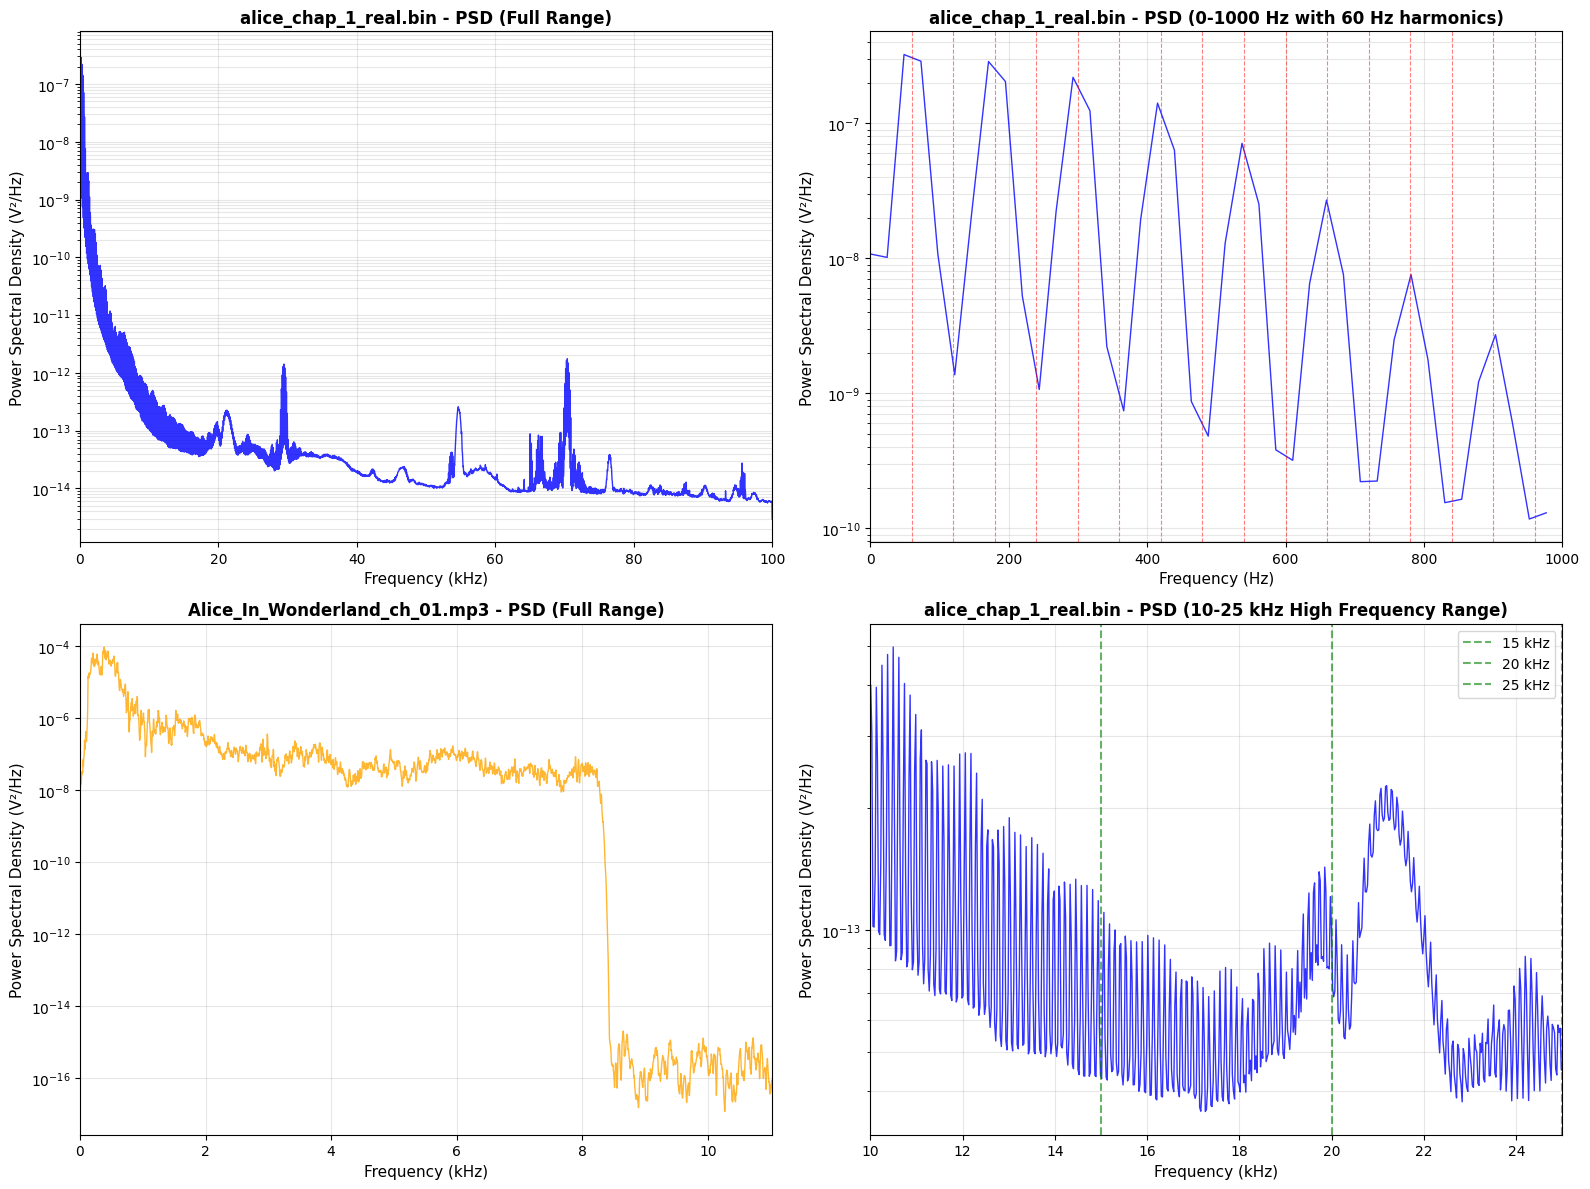

✓ PSD Analysis Complete
  Powerline frequency resolution: 24.41 Hz
  MP3 frequency resolution: 2.69 Hz
  Analysis duration: 60.0 seconds

  Top 5 dominant frequencies (0-1000 Hz):
    1. 48.8 Hz: 3.23e-07 V²/Hz
    2. 73.2 Hz: 2.89e-07 V²/Hz
    3. 170.9 Hz: 2.87e-07 V²/Hz
    4. 293.0 Hz: 2.19e-07 V²/Hz
    5. 195.3 Hz: 2.04e-07 V²/Hz


In [16]:
# === POWER SPECTRAL DENSITY ANALYSIS ===
from scipy.signal import welch

if librosa_available and len(SELECTED_FILES) > 0:
    for idx, (real_file, mp3_file) in enumerate(SELECTED_FILES):
        real_name = os.path.basename(real_file)
        mp3_name = os.path.basename(mp3_file)
        
        try:
            # Load binary file
            real_data = np.fromfile(real_file, dtype=np.float32)
            if len(real_data) == 0:
                continue
            
            # Load MP3 file
            mp3_data, mp3_sr = librosa.load(mp3_file, sr=None, mono=True)
            
            # Use sample rate from globals
            fs_real = globals().get('SAMPLE_RATE', 200000)
            fs_mp3 = mp3_sr
            
            # Find peak and align signal
            offset_sec, peak_sample = find_time_offset_from_peak(real_data, fs_real, search_duration_sec=7)
            real_data_aligned = real_data[peak_sample:]
            
            # Limit to first 60 seconds for PSD analysis
            analysis_duration = 60.0
            max_samples_real = min(len(real_data_aligned), int(analysis_duration * fs_real))
            max_samples_mp3 = min(len(mp3_data), int(analysis_duration * fs_mp3))
            
            analysis_real = real_data_aligned[:max_samples_real]
            analysis_mp3 = mp3_data[:max_samples_mp3]
            
            print(f"\n📊 Computing Power Spectral Density for {real_name} and {mp3_name}...")
            
            # Compute PSD for powerline signal
            nperseg_real = min(len(analysis_real), 8192)
            f_real, psd_real = welch(analysis_real, fs=fs_real, nperseg=nperseg_real, 
                                     noverlap=nperseg_real//2, scaling='density')
            
            # Compute PSD for MP3 signal
            nperseg_mp3 = min(len(analysis_mp3), 8192)
            f_mp3, psd_mp3 = welch(analysis_mp3, fs=fs_mp3, nperseg=nperseg_mp3, 
                                   noverlap=nperseg_mp3//2, scaling='density')
            
            # Create figure with 4 subplots for different frequency ranges
            fig, axes = plt.subplots(2, 2, figsize=(16, 12))
            
            # Plot 1: Powerline PSD - Full range (log scale)
            axes[0, 0].semilogy(f_real/1000, psd_real, 'b-', linewidth=1.0, alpha=0.8)
            axes[0, 0].set_title(f'{real_name} - PSD (Full Range)', fontsize=12, fontweight='bold')
            axes[0, 0].set_xlabel('Frequency (kHz)', fontsize=11)
            axes[0, 0].set_ylabel('Power Spectral Density (V²/Hz)', fontsize=11)
            axes[0, 0].grid(True, alpha=0.3, which='both')
            axes[0, 0].set_xlim(0, fs_real/2000)
            
            # Plot 2: Powerline PSD - Low frequency (0-1000 Hz)
            idx_low = np.where((f_real >= 0) & (f_real <= 1000))[0]
            axes[0, 1].semilogy(f_real[idx_low], psd_real[idx_low], 'b-', linewidth=1.0, alpha=0.8)
            
            # Mark 60 Hz harmonics
            for n in range(1, 17):  # First 16 harmonics
                harmonic_freq = 60 * n
                if harmonic_freq <= 1000:
                    axes[0, 1].axvline(x=harmonic_freq, color='red', linestyle='--', 
                                      linewidth=0.8, alpha=0.5)
            
            axes[0, 1].set_title(f'{real_name} - PSD (0-1000 Hz with 60 Hz harmonics)', 
                                fontsize=12, fontweight='bold')
            axes[0, 1].set_xlabel('Frequency (Hz)', fontsize=11)
            axes[0, 1].set_ylabel('Power Spectral Density (V²/Hz)', fontsize=11)
            axes[0, 1].grid(True, alpha=0.3, which='both')
            axes[0, 1].set_xlim(0, 1000)
            
            # Plot 3: MP3 PSD - Full range (log scale)
            axes[1, 0].semilogy(f_mp3/1000, psd_mp3, 'orange', linewidth=1.0, alpha=0.8)
            axes[1, 0].set_title(f'{mp3_name} - PSD (Full Range)', fontsize=12, fontweight='bold')
            axes[1, 0].set_xlabel('Frequency (kHz)', fontsize=11)
            axes[1, 0].set_ylabel('Power Spectral Density (V²/Hz)', fontsize=11)
            axes[1, 0].grid(True, alpha=0.3, which='both')
            axes[1, 0].set_xlim(0, fs_mp3/2000)
            
            # Plot 4: Powerline PSD - High frequency (10-25 kHz)
            idx_high = np.where((f_real >= 10000) & (f_real <= 25000))[0]
            axes[1, 1].semilogy(f_real[idx_high]/1000, psd_real[idx_high], 'b-', 
                               linewidth=1.0, alpha=0.8)
            
            # Mark potential carrier frequencies
            for carrier in [15000, 20000, 25000]:
                if carrier >= 10000 and carrier <= 25000:
                    axes[1, 1].axvline(x=carrier/1000, color='green', linestyle='--', 
                                      linewidth=1.5, alpha=0.6, label=f'{carrier/1000:.0f} kHz')
            
            axes[1, 1].set_title(f'{real_name} - PSD (10-25 kHz High Frequency Range)', 
                                fontsize=12, fontweight='bold')
            axes[1, 1].set_xlabel('Frequency (kHz)', fontsize=11)
            axes[1, 1].set_ylabel('Power Spectral Density (V²/Hz)', fontsize=11)
            axes[1, 1].grid(True, alpha=0.3, which='both')
            axes[1, 1].set_xlim(10, 25)
            axes[1, 1].legend(loc='upper right')
            
            plt.tight_layout()
            plt.show()
            
            # Print statistics
            print(f"✓ PSD Analysis Complete")
            print(f"  Powerline frequency resolution: {f_real[1]-f_real[0]:.2f} Hz")
            print(f"  MP3 frequency resolution: {f_mp3[1]-f_mp3[0]:.2f} Hz")
            print(f"  Analysis duration: {analysis_duration:.1f} seconds")
            
            # Find dominant frequencies in powerline signal (0-1000 Hz)
            idx_dom = np.where((f_real >= 0) & (f_real <= 1000))[0]
            psd_dom = psd_real[idx_dom]
            f_dom = f_real[idx_dom]
            
            # Get top 5 peaks
            peak_indices = np.argsort(psd_dom)[-5:][::-1]
            print(f"\n  Top 5 dominant frequencies (0-1000 Hz):")
            for i, peak_idx in enumerate(peak_indices, 1):
                freq = f_dom[peak_idx]
                power = psd_dom[peak_idx]
                print(f"    {i}. {freq:.1f} Hz: {power:.2e} V²/Hz")
            
        except Exception as e:
            print(f'Error computing PSD for {real_name}/{mp3_name}: {e}')
            import traceback
            traceback.print_exc()
            continue

else:
    if not librosa_available:
        print("Cannot perform PSD analysis - librosa is required")
    else:
        print("No files selected for PSD analysis")


## Audio Playback

Play the binary files as audio for listening.

In [ ]:
# === PLAY REAL BINARY FILES AS AUDIO ===
from IPython.display import Audio, display

# Playback parameters
PLAYBACK_DURATION = 60.0  # seconds (adjust as needed)
PLAYBACK_START = 0.0      # start time in seconds

if 'ALL_BINARY_FILES' in globals() and len(ALL_BINARY_FILES) > 0:
    for idx, real_file in enumerate(ALL_BINARY_FILES):
        real_name = os.path.basename(real_file)
        
        try:
            # Load binary file
            real_data = np.fromfile(real_file, dtype=np.float32)
            if len(real_data) == 0:
                print(f'No data in {real_name}, skipping')
                continue
            
            # Use sample rate from globals
            fs_real = globals().get('SAMPLE_RATE', 200000)
            
            # Calculate sample range for playback
            start_sample = int(PLAYBACK_START * fs_real)
            playback_samples = int(PLAYBACK_DURATION * fs_real)
            end_sample = min(start_sample + playback_samples, len(real_data))
            
            # Extract segment for playback
            playback_segment = real_data[start_sample:end_sample]
            actual_duration = len(playback_segment) / fs_real
            
            # Normalize to prevent clipping
            max_val = np.max(np.abs(playback_segment))
            if max_val > 0:
                playback_segment = playback_segment / max_val * 0.9
            
            print(f"\n🔊 {real_name}")
            print(f"   Sample rate: {fs_real:,} Hz")
            print(f"   Duration: {actual_duration:.2f}s (from {PLAYBACK_START:.2f}s)")
            print(f"   Total samples: {len(playback_segment):,}")
            
            # Display audio player
            display(Audio(playback_segment, rate=fs_real))
            
        except Exception as e:
            print(f'Error playing {real_name}: {e}')
            continue

else:
    print("No binary files available for playback")
    print("Please run the FILE SELECTION cell first")

In [ ]:
# === LOW PASS FILTERING (1 kHz Cutoff) ===
from scipy.signal import butter, filtfilt
from IPython.display import Audio, display

def lowpass_filter(data, cutoff, fs, order=5):
    """Apply low pass Butterworth filter"""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

if librosa_available and len(SELECTED_FILES) > 0:
    for idx, (real_file, mp3_file) in enumerate(SELECTED_FILES):
        real_name = os.path.basename(real_file)
        
        try:
            # Load binary file
            real_data = np.fromfile(real_file, dtype=np.float32)
            if len(real_data) == 0:
                continue
            
            # Use sample rate from globals or default
            fs_real = globals().get('SAMPLE_RATE', 200000)
            
            # Find peak and align signal
            offset_sec, peak_sample = find_time_offset_from_peak(real_data, fs_real, search_duration_sec=7)
            real_data_aligned = real_data[peak_sample:]
            
            # Apply low pass filter with 1 kHz cutoff
            filtered_data = lowpass_filter(real_data_aligned, cutoff=1000, fs=fs_real, order=5)
            
            # Create time axis
            t_real = np.arange(len(real_data_aligned)) / float(fs_real)
            
            # Limit display to 80 seconds
            max_time = 80
            max_samples = min(len(real_data_aligned), int(max_time * fs_real))
            
            show_original = real_data_aligned[:max_samples]
            show_filtered = filtered_data[:max_samples]
            t_show = t_real[:max_samples]
            
            # Create comparison plot: Original vs Filtered
            fig, axes = plt.subplots(2, 1, figsize=(14, 10))
            
            # 1. Original signal
            axes[0].plot(t_show, show_original, 'b-', linewidth=0.8, alpha=0.8)
            axes[0].set_title(f'{real_name} - Original Aligned Signal')
            axes[0].set_xlabel('Time (s)')
            axes[0].set_ylabel('Amplitude')
            axes[0].grid(True, alpha=0.3)
            axes[0].set_xlim(0, max_time)
            
            # 2. Filtered signal
            axes[1].plot(t_show, show_filtered, 'r-', linewidth=0.8, alpha=0.8)
            axes[1].set_title(f'{real_name} - After 1 kHz Low Pass Filter')
            axes[1].set_xlabel('Time (s)')
            axes[1].set_ylabel('Amplitude')
            axes[1].grid(True, alpha=0.3)
            axes[1].set_xlim(0, max_time)
            
            plt.tight_layout()
            plt.show()
            
            # Audio playback of filtered signal
            print(f"\n🔊 AUDIO PLAYBACK - Filtered Signal (1 kHz Low Pass)")
            
            # Prepare audio segment (first 60 seconds)
            playback_duration = 60.0
            playback_samples = min(len(filtered_data), int(playback_duration * fs_real))
            audio_segment = filtered_data[:playback_samples]
            
            # Normalize to prevent clipping
            max_val = np.max(np.abs(audio_segment))
            if max_val > 0:
                audio_segment = audio_segment / max_val * 0.9
            
            actual_duration = len(audio_segment) / fs_real
            print(f"   File: {real_name}")
            print(f"   Sample rate: {fs_real:,} Hz")
            print(f"   Duration: {actual_duration:.2f}s")
            print(f"   Filter: 1 kHz Low Pass (5th order Butterworth)")
            
            # Display audio player
            display(Audio(audio_segment, rate=fs_real))
            
        except Exception as e:
            print(f'Error filtering {real_name}: {e}')
            import traceback
            traceback.print_exc()
            continue


[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?



🎵 Extracting odd 60 Hz harmonics from powerline signal...
   Extracting 208 odd harmonics: [60, 180, 300, 420, 540, 660, 780, 900, 1020, 1140, 1260, 1380, 1500, 1620, 1740, 1860, 1980, 2100, 2220, 2340, 2460, 2580, 2700, 2820, 2940, 3060, 3180, 3300, 3420, 3540, 3660, 3780, 3900, 4020, 4140, 4260, 4380, 4500, 4620, 4740, 4860, 4980, 5100, 5220, 5340, 5460, 5580, 5700, 5820, 5940, 6060, 6180, 6300, 6420, 6540, 6660, 6780, 6900, 7020, 7140, 7260, 7380, 7500, 7620, 7740, 7860, 7980, 8100, 8220, 8340, 8460, 8580, 8700, 8820, 8940, 9060, 9180, 9300, 9420, 9540, 9660, 9780, 9900, 10020, 10140, 10260, 10380, 10500, 10620, 10740, 10860, 10980, 11100, 11220, 11340, 11460, 11580, 11700, 11820, 11940, 12060, 12180, 12300, 12420, 12540, 12660, 12780, 12900, 13020, 13140, 13260, 13380, 13500, 13620, 13740, 13860, 13980, 14100, 14220, 14340, 14460, 14580, 14700, 14820, 14940, 15060, 15180, 15300, 15420, 15540, 15660, 15780, 15900, 16020, 16140, 16260, 16380, 16500, 16620, 16740, 16860, 16980, 17100

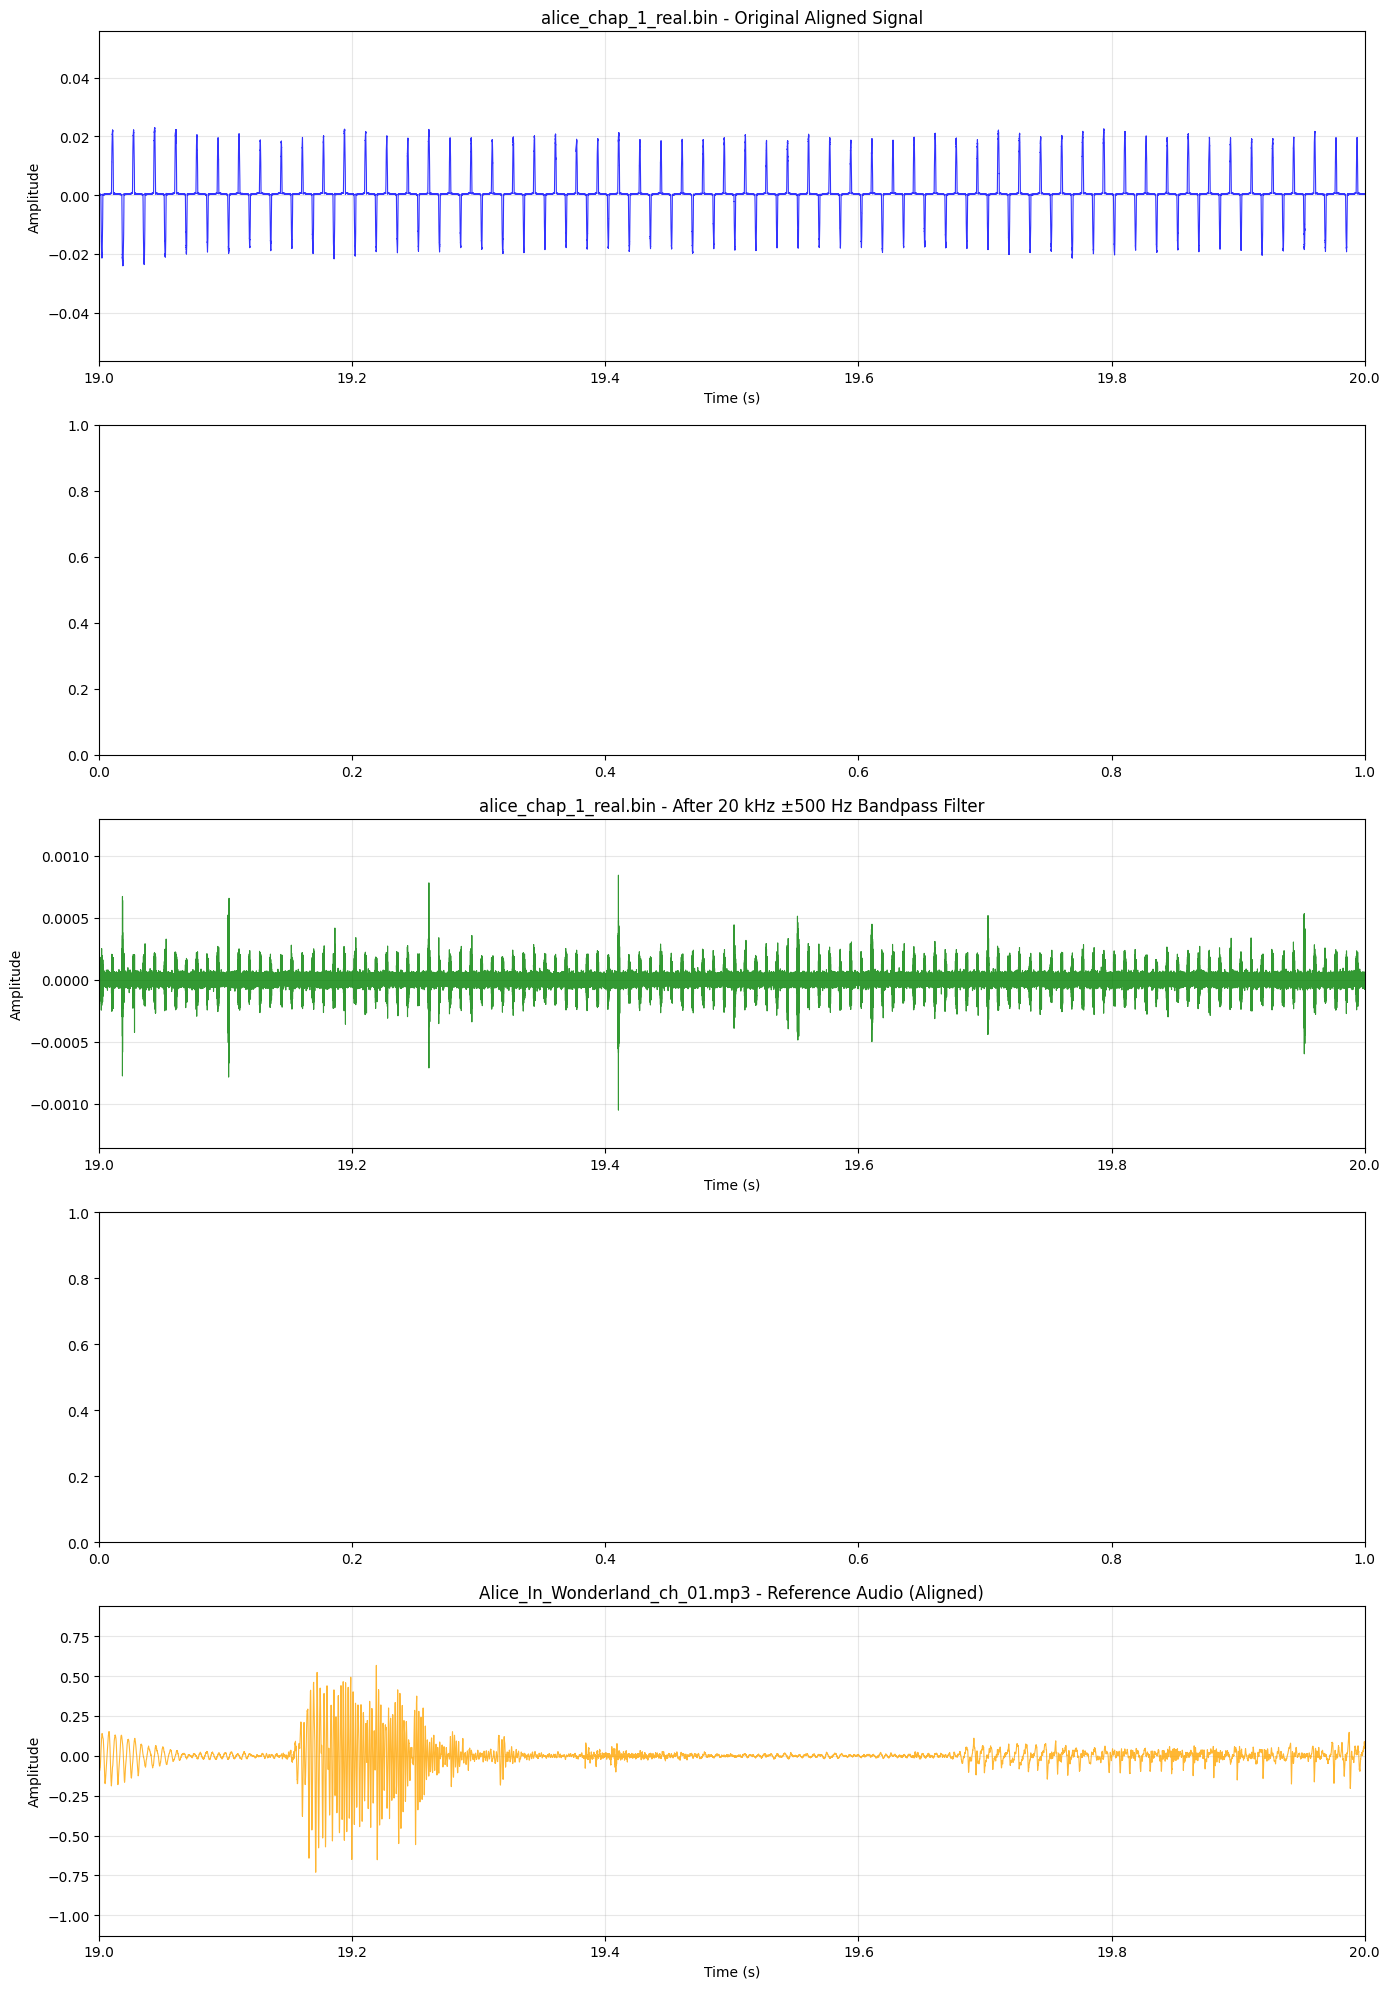

In [17]:
# === BANDPASS FILTERING (10-25 kHz) ===
from scipy.signal import butter, sosfiltfilt, hilbert, resample_poly
from IPython.display import Audio, display

# PLOTTING TIME RANGE PARAMETERS
PLOT_START_TIME = 19  # Start time for plotting (seconds)
PLOT_END_TIME = 20    # End time for plotting (seconds)

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Apply bandpass Butterworth filter"""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    sos = butter(order, [low, high], btype='band', analog=False, output='sos')
    y = sosfiltfilt(sos, data)
    return y

def shift_to_audible(data, original_fs, target_fs=22050):
    """
    Extract envelope and downsample to audible range
    """
    # Extract envelope using Hilbert transform
    analytic_signal = hilbert(data)
    envelope = np.abs(analytic_signal)
    
    # Downsample to target sample rate
    if original_fs != target_fs:
        # Calculate downsampling ratio
        gcd = np.gcd(int(original_fs), int(target_fs))
        up = target_fs // gcd
        down = int(original_fs) // gcd
        
        # Resample
        envelope_resampled = resample_poly(envelope, up, down)
    else:
        envelope_resampled = envelope
    
    return envelope_resampled

def extract_odd_harmonics(data, fs, fundamental=60, max_freq=25000, bandwidth=20):
    """
    Extract odd harmonics of the fundamental frequency
    
    Parameters:
    - data: input signal
    - fs: sampling frequency
    - fundamental: fundamental frequency (Hz)
    - max_freq: maximum frequency to consider (Hz)
    - bandwidth: bandwidth around each harmonic (Hz)
    
    Returns:
    - combined_harmonics: sum of normalized odd harmonics
    """
    # Calculate odd harmonics under max_freq
    harmonics = []
    n = 1
    while True:
        harmonic_freq = fundamental * (2*n - 1)  # Odd harmonics: 1, 3, 5, 7, ...
        if harmonic_freq > max_freq:
            break
        harmonics.append(harmonic_freq)
        n += 1
    
    print(f"   Extracting {len(harmonics)} odd harmonics: {[int(h) for h in harmonics]} Hz")
    
    # Extract each harmonic with bandpass filter
    harmonic_signals = []
    for harmonic_freq in harmonics:
        lowcut = harmonic_freq - bandwidth/2
        highcut = harmonic_freq + bandwidth/2
        
        # Apply bandpass filter
        filtered = bandpass_filter(data, lowcut, highcut, fs, order=5)
        
        # Normalize
        max_val = np.max(np.abs(filtered))
        if max_val > 0:
            filtered = filtered / max_val
        
        harmonic_signals.append(filtered)
    
    # Sum all normalized harmonics
    combined_harmonics = np.sum(harmonic_signals, axis=0)
    
    return combined_harmonics, harmonics

if librosa_available and len(SELECTED_FILES) > 0:
    for idx, (real_file, mp3_file) in enumerate(SELECTED_FILES):
        real_name = os.path.basename(real_file)
        mp3_name = os.path.basename(mp3_file)
        
        try:
            # Load binary file
            real_data = np.fromfile(real_file, dtype=np.float32)
            if len(real_data) == 0:
                continue
            
            # Load MP3 file
            mp3_data, mp3_sr = librosa.load(mp3_file, sr=None, mono=True)
            
            # Use sample rate from globals or default
            fs_real = globals().get('SAMPLE_RATE', 200000)
            fs_mp3 = mp3_sr
            
            # Find peak and align signal
            offset_sec, peak_sample = find_time_offset_from_peak(real_data, fs_real, search_duration_sec=7)
            real_data_aligned = real_data[peak_sample:]
            
            # Extract odd harmonics from raw powerline signal
            print(f"\n🎵 Extracting odd 60 Hz harmonics from powerline signal...")
            combined_harmonics, harmonic_freqs = extract_odd_harmonics(
                real_data_aligned, fs_real, fundamental=60, max_freq=25000, bandwidth=20
            )
            
            # Apply bandpass filter (20-80 kHz)
            bandpassed_data = bandpass_filter(real_data_aligned, lowcut=20000, highcut=80000, fs=fs_real, order=5)
            
            # Create time axes
            t_real = np.arange(len(real_data_aligned)) / float(fs_real)
            t_mp3 = np.arange(len(mp3_data)) / float(fs_mp3)
            
            # Calculate display time range
            plot_duration = PLOT_END_TIME - PLOT_START_TIME
            max_time = PLOT_END_TIME
            max_samples_real = min(len(real_data_aligned), int(max_time * fs_real))
            max_samples_mp3 = min(len(mp3_data), int(max_time * fs_mp3))
            
            show_original = real_data_aligned[:max_samples_real]
            show_bandpassed = bandpassed_data[:max_samples_real]
            #show_harmonics = combined_harmonics[:max_samples_real]
            show_mp3 = mp3_data[:max_samples_mp3]
            t_show_real = t_real[:max_samples_real]
            t_show_mp3 = t_mp3[:max_samples_mp3]
            
            # Also create a zoomed view (1 second) to see high frequency oscillations
            zoom_time = 1
            zoom_samples = int(zoom_time * fs_real)
            zoom_start_sample = int(PLOT_START_TIME * fs_real)
            show_bandpassed_zoom = bandpassed_data[zoom_start_sample:zoom_start_sample+zoom_samples]
            #show_harmonics_zoom = combined_harmonics[zoom_start_sample:zoom_start_sample+zoom_samples]
            t_zoom = np.arange(len(show_bandpassed_zoom)) / fs_real
            
            # Create comparison plot
            fig, axes = plt.subplots(5, 1, figsize=(14, 20))
            
            # 1. Original aligned signal
            axes[0].plot(t_show_real, show_original, 'b-', linewidth=0.8, alpha=0.8)
            axes[0].set_title(f'{real_name} - Original Aligned Signal')
            axes[0].set_xlabel('Time (s)')
            axes[0].set_ylabel('Amplitude')
            axes[0].grid(True, alpha=0.3)
            axes[0].set_xlim(PLOT_START_TIME, PLOT_END_TIME)
            
            # # 2. Combined odd harmonics
            # axes[1].plot(t_show_real, show_harmonics, 'purple', linewidth=0.8, alpha=0.8)
            # axes[1].set_title(f'Combined Odd 60 Hz Harmonics (Normalized & Summed) - {len(harmonic_freqs)} harmonics')
            # axes[1].set_xlabel('Time (s)')
            # axes[1].set_ylabel('Amplitude')
            # axes[1].grid(True, alpha=0.3)
            # axes[1].set_xlim(PLOT_START_TIME, PLOT_END_TIME)
            
            # 3. Bandpassed signal - Full view
            axes[2].plot(t_show_real, show_bandpassed, 'g-', linewidth=0.8, alpha=0.8)
            axes[2].set_title(f'{real_name} - After 20 kHz ±500 Hz Bandpass Filter')
            axes[2].set_xlabel('Time (s)')
            axes[2].set_ylabel('Amplitude')
            axes[2].grid(True, alpha=0.3)
            axes[2].set_xlim(PLOT_START_TIME, PLOT_END_TIME)
            
            # # 4. Zoomed comparison: Harmonics vs Bandpassed
            # axes[3].plot(t_zoom, show_harmonics_zoom, 'purple', linewidth=1.0, alpha=0.7, label='Odd Harmonics')
            # axes[3].plot(t_zoom, show_bandpassed_zoom, 'g-', linewidth=1.0, alpha=0.7, label='20 kHz Bandpass')
            # axes[3].set_title(f'Zoomed Comparison ({PLOT_START_TIME}-{PLOT_START_TIME+1} sec)')
            # axes[3].set_xlabel('Time (s)')
            # axes[3].set_ylabel('Amplitude')
            # axes[3].grid(True, alpha=0.3)
            # axes[3].legend()
            # axes[3].set_xlim(0, zoom_time)
            
            # 5. MP3 reference signal (aligned to same time axis)
            axes[4].plot(t_show_mp3, show_mp3, 'orange', linewidth=0.8, alpha=0.8)
            axes[4].set_title(f'{mp3_name} - Reference Audio (Aligned)')
            axes[4].set_xlabel('Time (s)')
            axes[4].set_ylabel('Amplitude')
            axes[4].grid(True, alpha=0.3)
            axes[4].set_xlim(PLOT_START_TIME, PLOT_END_TIME)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f'Error bandpass filtering {real_name}: {e}')
            import traceback
            traceback.print_exc()
            continue

else:
    print("No files selected for bandpass filtering analysis")


In [ ]:
# Extract envelope and downsample to audible range for full signal
            print(f"\n📊 Extracting and downsampling envelope from bandpassed signal...")
            target_fs = 22050  # Standard audio sample rate
            envelope_downsampled = shift_to_audible(bandpassed_data, fs_real, target_fs)
            
            # Create time axis for downsampled envelope
            t_envelope_full = np.arange(len(envelope_downsampled)) / target_fs
            
            # Create detailed comparison at 10-11 second mark
            comparison_start = 10.0  # seconds
            comparison_duration = 1.0  # seconds
            
            # Extract segments for comparison
            start_sample_envelope = int(comparison_start * target_fs)
            end_sample_envelope = int((comparison_start + comparison_duration) * target_fs)
            start_sample_mp3 = int(comparison_start * fs_mp3)
            end_sample_mp3 = int((comparison_start + comparison_duration) * fs_mp3)
            
            if end_sample_envelope <= len(envelope_downsampled) and end_sample_mp3 <= len(mp3_data):
                envelope_segment = envelope_downsampled[start_sample_envelope:end_sample_envelope]
                mp3_segment = mp3_data[start_sample_mp3:end_sample_mp3]
                
                # Create time axes for segments
                t_envelope = np.arange(len(envelope_segment)) / target_fs
                t_mp3_segment = np.arange(len(mp3_segment)) / fs_mp3
                
                # Normalize both signals for comparison
                envelope_norm = envelope_segment / (np.max(np.abs(envelope_segment)) + 1e-10)
                mp3_norm = mp3_segment / (np.max(np.abs(mp3_segment)) + 1e-10)
                
                # Create comparison plot
                fig, axes = plt.subplots(3, 1, figsize=(14, 12))
                
                # Plot 1: Downsampled envelope
                axes[0].plot(t_envelope, envelope_norm, 'r-', linewidth=1.5, label='Downsampled Envelope (Normalized)')
                axes[0].set_title(f'Downsampled Envelope ({target_fs} Hz) from Bandpassed Signal ({comparison_start}-{comparison_start+comparison_duration} sec)', 
                                 fontsize=12, fontweight='bold')
                axes[0].set_xlabel('Time (s)')
                axes[0].set_ylabel('Normalized Amplitude')
                axes[0].grid(True, alpha=0.3)
                axes[0].legend()
                axes[0].set_xlim(0, comparison_duration)
                
                # Plot 2: MP3 reference
                axes[1].plot(t_mp3_segment, mp3_norm, 'orange', linewidth=1.5, label='MP3 Reference (Normalized)')
                axes[1].set_title(f'MP3 Reference Signal ({comparison_start}-{comparison_start+comparison_duration} sec)', 
                                 fontsize=12, fontweight='bold')
                axes[1].set_xlabel('Time (s)')
                axes[1].set_ylabel('Normalized Amplitude')
                axes[1].grid(True, alpha=0.3)
                axes[1].legend()
                axes[1].set_xlim(0, comparison_duration)
                
                # Plot 3: Overlay comparison
                axes[2].plot(t_envelope, envelope_norm, 'r-', linewidth=1.5, alpha=0.7, label='Downsampled Envelope')
                axes[2].plot(t_mp3_segment, mp3_norm, 'orange', linewidth=1.5, alpha=0.7, label='MP3 Reference')
                axes[2].set_title(f'Overlay Comparison ({comparison_start}-{comparison_start+comparison_duration} sec)', 
                                 fontsize=12, fontweight='bold')
                axes[2].set_xlabel('Time (s)')
                axes[2].set_ylabel('Normalized Amplitude')
                axes[2].grid(True, alpha=0.3)
                axes[2].legend()
                axes[2].set_xlim(0, comparison_duration)
                
                plt.tight_layout()
                plt.show()
                
                print(f"✓ Comparison plot complete for {comparison_start}-{comparison_start+comparison_duration} second window")
                print(f"  Envelope sample rate: {target_fs} Hz")
                print(f"  MP3 sample rate: {fs_mp3} Hz")
            
            # Audio playback of bandpassed signal (shifted to audible range)
            print(f"\n🔊 AUDIO PLAYBACK - Bandpassed Signal (Shifted to Audible Range)")
            
            # Prepare audio segment (first 60 seconds of envelope)
            playback_duration = 60.0
            playback_samples_envelope = min(len(envelope_downsampled), int(playback_duration * target_fs))
            audio_audible = envelope_downsampled[:playback_samples_envelope]
            
            # Normalize to prevent clipping
            max_val = np.max(np.abs(audio_audible))
            if max_val > 0:
                audio_audible = audio_audible / max_val * 0.9
            
            actual_duration = len(audio_audible) / target_fs
            print(f"   File: {real_name}")
            print(f"   Original sample rate: {fs_real:,} Hz")
            print(f"   Playback sample rate: {target_fs:,} Hz")
            print(f"   Duration: {actual_duration:.2f}s")
            print(f"   Filter: 10-25 kHz Bandpass (5th order Butterworth)")
            print(f"   Processing: Envelope extraction + downsampling to audible range")
            
            # Display audio player
            display(Audio(audio_audible, rate=target_fs))
            
        except Exception as e:
            print(f'Error bandpass filtering {real_name}: {e}')
            import traceback
            traceback.print_exc()
            continue

else:
    print("No files selected for bandpass filtering analysis")


📊 Computing Enhanced Spectrogram for alice_chap_1_real.bin
  Time range: 0s - 50s
  Computing high-resolution spectrogram...


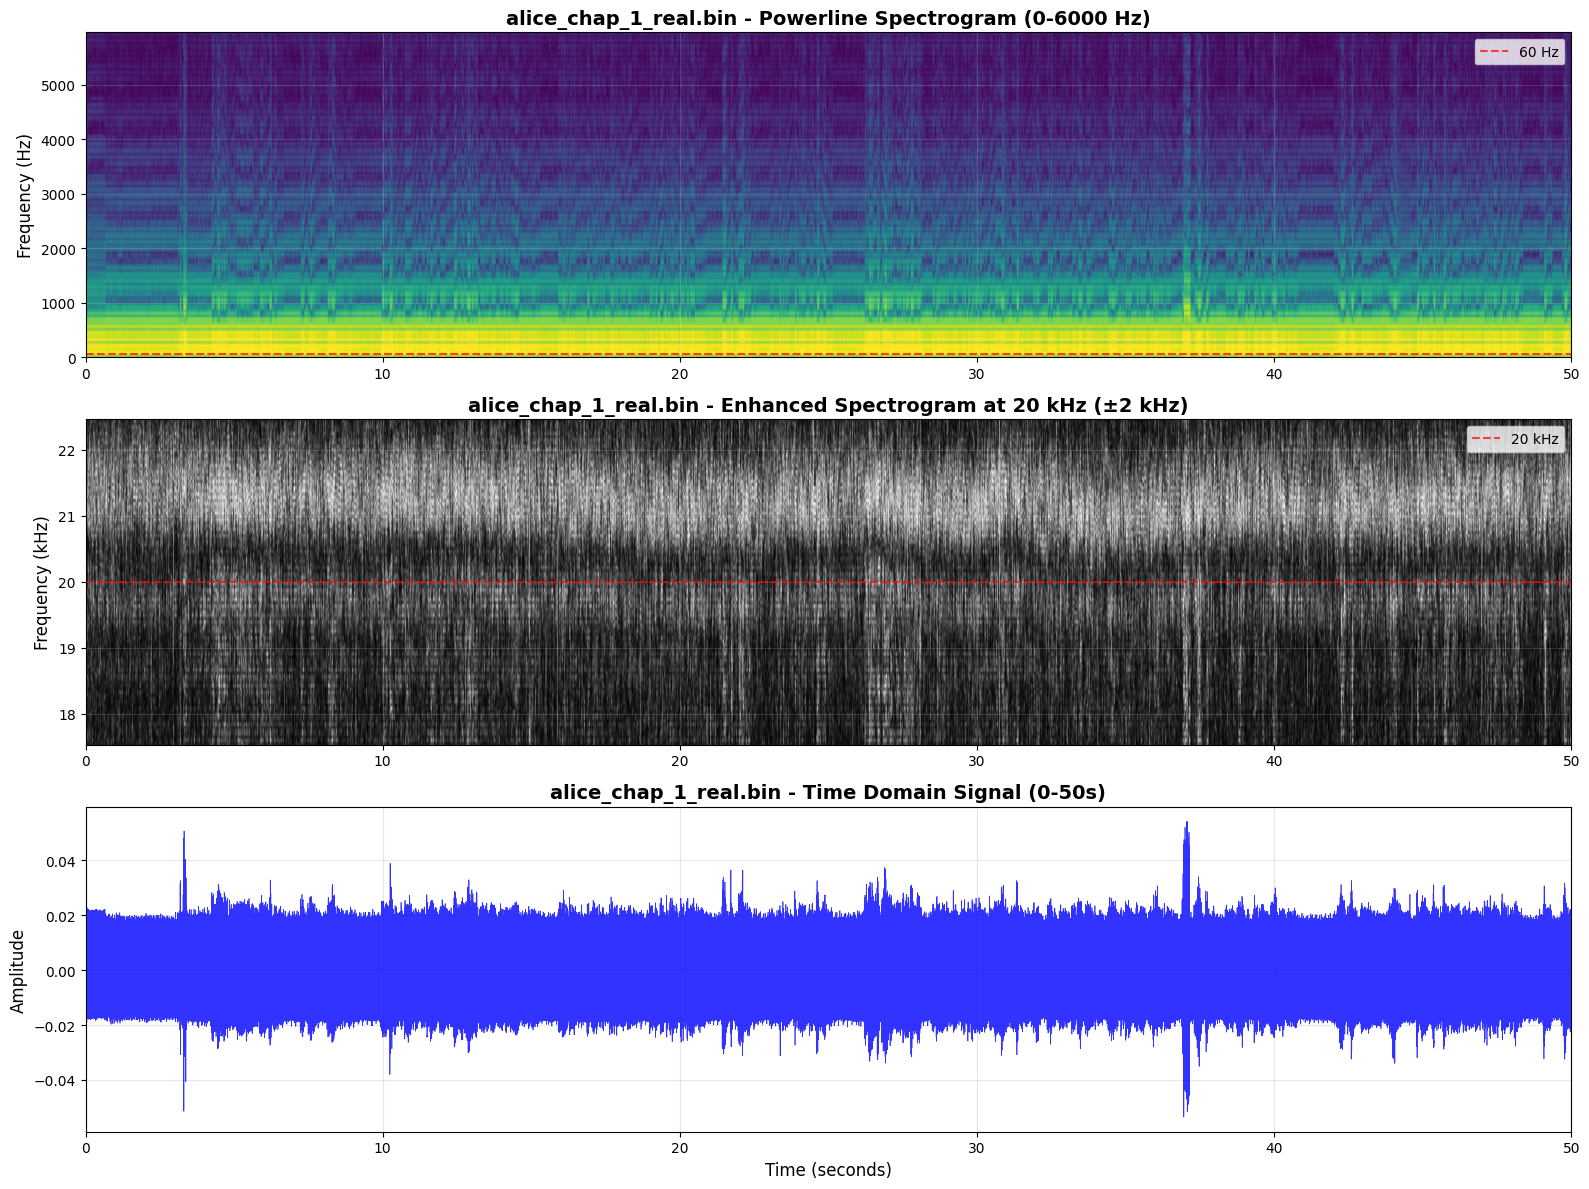


✓ Enhanced spectrogram analysis complete for alice_chap_1_real.bin
  Low freq range: 0 - 6000 Hz
  High freq range: 17.5 - 22.5 kHz
  Time duration: 50 seconds
  Frequency resolution: 48.83 Hz
  Time resolution: 0.002 seconds
📊 Computing Enhanced Spectrogram for idle_97_real.bin
  Time range: 0s - 50s
  Computing high-resolution spectrogram...



✓ Enhanced spectrogram analysis complete for idle_97_real.bin
  Low freq range: 0 - 6000 Hz
  High freq range: 17.5 - 22.5 kHz
  Time duration: 50 seconds
  Frequency resolution: 48.83 Hz
  Time resolution: 0.002 seconds

🎯 Enhanced spectrogram visualization complete


In [25]:
# === ENHANCED SPECTROGRAM ANALYSIS (20 kHz ± 5 kHz) ===
from scipy.signal import spectrogram, get_window

# Enhanced spectrogram parameters
FREQ_MIN_ENHANCED = 0      # Start frequency (Hz)
FREQ_MAX_ENHANCED = 6000    # End frequency (Hz)
START_TIME_SEC = 0         # Start time for analysis
DURATION_SEC = 50          # Duration for analysis

# Processing parameters for enhanced spectrograms
center_freq = 20000        # 20 kHz center frequency
bandwidth_spec = 5000     # 20 kHz total bandwidth (±10 kHz)

if librosa_available and len(ALL_BINARY_FILES) > 0:
    for idx, real_file in enumerate(ALL_BINARY_FILES):
        real_name = os.path.basename(real_file)
        
        try:
            # Load binary file
            real_data = np.fromfile(real_file, dtype=np.float32)
            if len(real_data) == 0:
                print(f'No data in {real_name}, skipping')
                continue
            
            # Use sample rate from globals
            fs_real = globals().get('SAMPLE_RATE', 200000)
            
            print(f"📊 Computing Enhanced Spectrogram for {real_name}")
            print(f"  Time range: {START_TIME_SEC}s - {START_TIME_SEC + DURATION_SEC}s")
            
            # Limit to specified duration
            max_samples_real = min(len(real_data), int(DURATION_SEC * fs_real))
            analysis_data = real_data[:max_samples_real]
            
            # Enhanced spectrogram parameters
            nperseg_spec = 4096  # Larger window for better frequency resolution
            noverlap_spec = int(nperseg_spec * 0.9)  # 90% overlap for smoother time resolution
            
            # Use Hann window to reduce spectral leakage
            window = get_window('hann', nperseg_spec)
            
            print("  Computing high-resolution spectrogram...")
            f_spec_real, t_spec_real, Sxx_real = spectrogram(analysis_data, fs=fs_real, 
                                                              nperseg=nperseg_spec, 
                                                              noverlap=noverlap_spec,
                                                              window=window)
            
            # Convert to dB
            Sxx_db = 10 * np.log10(Sxx_real + 1e-12)
            
            # Create three frequency ranges for analysis
            # 1. Low frequency (0-100 Hz) - powerline analysis
            freq_mask_low = (f_spec_real >= FREQ_MIN_ENHANCED) & (f_spec_real <= FREQ_MAX_ENHANCED)
            f_low = f_spec_real[freq_mask_low]
            Sxx_low = Sxx_db[freq_mask_low, :]
            
            # 2. High frequency (20 kHz ± 5 kHz) - enhanced analysis
            freq_min_high = center_freq - bandwidth_spec / 2  # 15 kHz
            freq_max_high = center_freq + bandwidth_spec / 2  # 25 kHz
            freq_mask_high = (f_spec_real >= freq_min_high) & (f_spec_real <= freq_max_high)
            f_high = f_spec_real[freq_mask_high]
            Sxx_high = Sxx_db[freq_mask_high, :]
            
            # Create time axis
            time_axis = np.arange(len(analysis_data)) / fs_real
            
            # Create figure with 3 subplots
            fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12))
            
            # Plot 1: Low frequency spectrogram (0-100 Hz)
            if len(f_low) > 0:
                vmin_low = np.percentile(Sxx_low, 3)
                vmax_low = np.percentile(Sxx_low, 97)
                
                im1 = ax1.imshow(Sxx_low, aspect='auto', origin='lower',
                                extent=[0, DURATION_SEC, f_low.min(), f_low.max()],
                                cmap='viridis', interpolation='bilinear',
                                vmin=vmin_low, vmax=vmax_low)
                
                ax1.set_title(f'{real_name} - Powerline Spectrogram (0-{FREQ_MAX_ENHANCED} Hz)', 
                              fontsize=14, fontweight='bold')
                ax1.set_ylabel('Frequency (Hz)', fontsize=12)
                ax1.set_xlim(0, DURATION_SEC)
                ax1.axhline(y=60, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='60 Hz')
                ax1.legend(loc='upper right')
                ax1.grid(True, alpha=0.2, color='white', linewidth=0.5)
                
                #plt.colorbar(im1, ax=ax1, label='Power/Frequency (dB/Hz)')
            
            # Plot 2: High frequency spectrogram (20 kHz ± 5 kHz)
            if len(f_high) > 0:
                vmin_high = np.percentile(Sxx_high, 5)
                vmax_high = np.percentile(Sxx_high, 95)
                
                im2 = ax2.imshow(Sxx_high, aspect='auto', origin='lower',
                                extent=[0, DURATION_SEC, f_high.min()/1000, f_high.max()/1000],
                                cmap='gray', interpolation='bilinear',
                                vmin=vmin_high, vmax=vmax_high)
                
                ax2.set_title(f'{real_name} - Enhanced Spectrogram at {center_freq/1000:.0f} kHz (±{bandwidth_spec/2000:.0f} kHz)', 
                              fontsize=14, fontweight='bold')
                ax2.set_ylabel('Frequency (kHz)', fontsize=12)
                ax2.set_xlim(0, DURATION_SEC)
                ax2.axhline(y=center_freq/1000, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
                           label=f'{center_freq/1000:.0f} kHz')
                ax2.legend(loc='upper right')
                ax2.grid(True, alpha=0.2, color='white', linewidth=0.5)
                
                #plt.colorbar(im2, ax=ax2, label='Power/Frequency (dB/Hz)')
            
            # Plot 3: Time domain signal
            ax3.plot(time_axis, analysis_data, color='blue', linewidth=0.5, alpha=0.8)
            ax3.set_title(f'{real_name} - Time Domain Signal ({START_TIME_SEC}-{START_TIME_SEC+DURATION_SEC}s)', 
                          fontsize=14, fontweight='bold')
            ax3.set_xlabel('Time (seconds)', fontsize=12)
            ax3.set_ylabel('Amplitude', fontsize=12)
            ax3.set_xlim(0, DURATION_SEC)
            ax3.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print(f"\n✓ Enhanced spectrogram analysis complete for {real_name}")
            print(f"  Low freq range: {FREQ_MIN_ENHANCED} - {FREQ_MAX_ENHANCED} Hz")
            print(f"  High freq range: {freq_min_high/1000:.1f} - {freq_max_high/1000:.1f} kHz")
            print(f"  Time duration: {DURATION_SEC} seconds")
            print(f"  Frequency resolution: {f_spec_real[1]-f_spec_real[0]:.2f} Hz")
            print(f"  Time resolution: {t_spec_real[1]-t_spec_real[0]:.3f} seconds")
            
        except Exception as e:
            print(f'Error computing enhanced spectrogram for {real_name}: {e}')
            continue
    
    print('\n🎯 Enhanced spectrogram visualization complete')
else:
    print("No files available for enhanced spectrogram analysis")

In [ ]:
# === ENVELOPE EXTRACTION AND AUDIO PLAYBACK ===
from scipy.signal import hilbert

if os.path.exists(chirp_file) and 'combined_signal' in globals():
    print(f"📊 Extracting Envelope from Combined Harmonics Signal")
    
    try:
        # Extract envelope using Hilbert transform
        analytic_signal = hilbert(combined_signal)
        envelope = np.abs(analytic_signal)
        
        # Create comparison figure
        fig, axes = plt.subplots(3, 1, figsize=(16, 14))
        
        # Zoom to first 5 seconds for detailed view
        zoom_samples = int(5.0 * fs_chirp)
        t_zoom = t[:zoom_samples]
        
        # Plot 1: Combined harmonics signal (zoomed)
        axes[0].plot(t_zoom, combined_signal[:zoom_samples], 'b-', linewidth=0.8, alpha=0.7, label='Combined Harmonics')
        axes[0].set_title('Combined Harmonics Signal (0-5 seconds)', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Time (s)', fontsize=12)
        axes[0].set_ylabel('Normalized Amplitude', fontsize=12)
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc='upper right')
        
        # Plot 2: Envelope overlaid on signal (zoomed)
        axes[1].plot(t_zoom, combined_signal[:zoom_samples], 'b-', linewidth=0.5, alpha=0.4, label='Combined Harmonics')
        axes[1].plot(t_zoom, envelope[:zoom_samples], 'r-', linewidth=2.0, alpha=0.9, label='Envelope')
        axes[1].plot(t_zoom, -envelope[:zoom_samples], 'r-', linewidth=2.0, alpha=0.9)
        axes[1].set_title('Envelope Extraction (0-5 seconds)', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Time (s)', fontsize=12)
        axes[1].set_ylabel('Normalized Amplitude', fontsize=12)
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='upper right')
        
        # Plot 3: Envelope only (full duration)
        axes[2].plot(t, envelope, 'r-', linewidth=1.0, alpha=0.9, label='Envelope')
        axes[2].set_title('Envelope Signal (Full Duration)', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Time (s)', fontsize=12)
        axes[2].set_ylabel('Envelope Amplitude', fontsize=12)
        axes[2].grid(True, alpha=0.3)
        axes[2].legend(loc='upper right')
        axes[2].fill_between(t, 0, envelope, alpha=0.3, color='red')
        
        plt.tight_layout()
        plt.show()
        
        # Calculate envelope statistics
        envelope_rms = np.sqrt(np.mean(envelope**2))
        envelope_peak = np.max(envelope)
        envelope_mean = np.mean(envelope)
        
        print(f"\n📈 ENVELOPE STATISTICS:")
        print(f"  RMS:   {envelope_rms:.4f}")
        print(f"  Peak:  {envelope_peak:.4f}")
        print(f"  Mean:  {envelope_mean:.4f}")
        
        # Normalize envelope for audio playback
        audio_envelope = envelope / (np.max(envelope) + 1e-10) * 0.9
        
        print(f"\n🔊 AUDIO PLAYBACK:")
        print("  Playing envelope as audio...")
        print(f"  Sample rate: {fs_chirp:,} Hz")
        print(f"  Duration: {len(audio_envelope)/fs_chirp:.1f} seconds")
        
        # Display audio player for envelope
        display(Audio(audio_envelope, rate=fs_chirp))
        
    except Exception as e:
        print(f"❌ Error extracting envelope: {e}")
else:
    print("⚠️ Please run the harmonic filtering and combination cells first")